In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [4]:
poly_homopolymer_regions = [309,310,311,16179,16180,16181,16182,16183]

In [5]:
df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Seq_Tech', 'Center']] = df_pb['Sample'].str.split('-', expand=True)

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)

df = pd.concat([df_pb, df_ont])
# df = df.sort_values(['Tissue', 'Donor', 'Center'])

df['Seq_Tech'] = np.where(df['Seq_Tech'] == 'pacbio', 'PacBio', 'ONT')

df

,Sample,Total_Read_Count,ChrM_Read_Count,Kmer_Read_Count,Mito_Read_Count,mtDNA_CN,Mean_Read_Length,Median_Read_Length,Mito_Coverage,Nuclear_Coverage,Haplogroup,Donor,Seq_Tech,Center
0,hapmap-pacbio-washu,13473455,2845,2840,2748,2720.52,16435.23,16552.0,2723.49,95.11,R,hapmap,PacBio,washu
1,hapmap-pacbio-uwsc,9567626,849,849,837,803.52,16157.40,16546.0,814.99,64.99,R,hapmap,PacBio,uwsc
2,hapmap-pacbio-bcm,20364501,2963,2874,2855,2055.60,12158.79,12915.0,2093.01,102.85,R,hapmap,PacBio,bcm
3,hapmap-pacbio-broad,17552081,3260,3247,3221,2770.06,14198.58,15350.0,2757.75,97.39,R,hapmap,PacBio,broad
0,hapmap-ont-uwsc,44998307,147571,12984,11572,5091.68,7050.20,5576.5,4872.65,62.92,R,hapmap,ONT,uwsc
1,hapmap-ont-bcm,17770917,1906,1458,1349,1106.18,12801.82,15673.0,1034.45,111.91,R,hapmap,ONT,bcm
2,hapmap-ont-nygc,20149139,22118,8571,7416,3263.04,7584.89,6080.0,3361.60,83.68,R,hapmap,ONT,nygc


In [6]:
comb_sr_cov = pd.DataFrame(columns=['Sample', 'Mito_Coverage'])
sr_samples = ['hapmap-illumina-bcm', 'hapmap-illumina-broad', 'hapmap-illumina-nygc', 'hapmap-illumina-washu']
for sample in sr_samples:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mutect2/smaht/illumina/hapmap/mosdepth/{sample}.mosdepth.summary.txt'
    cov_df = pd.read_csv(file_path, sep='\t')
    cov = cov_df.loc[cov_df['chrom'] == 'chrM', 'mean'].item()
    comb_sr_cov.loc[len(comb_sr_cov)] = [sample, cov]
comb_sr_cov

comb_cov_df = pd.concat([comb_sr_cov, df[['Sample', 'Mito_Coverage']]])
comb_cov_df[['Donor', 'Seq_Tech', 'Center']] = comb_cov_df['Sample'].str.split('-', expand=True)
comb_cov_df = comb_cov_df.sort_values(['Center', 'Seq_Tech'])

comb_cov_df['Center'] = comb_cov_df['Center'].str.upper()

conditions = [
    (comb_cov_df['Seq_Tech'] == 'pacbio'),
    (comb_cov_df['Seq_Tech'] == 'ont'),
    (comb_cov_df['Seq_Tech'] == 'illumina'),
]

values = ['PacBio', 'ONT', 'Illumina']
comb_cov_df['Seq_Tech'] = np.select(conditions, values, default='Unknown')

comb_cov_df

,Sample,Mito_Coverage,Donor,Seq_Tech,Center
0,hapmap-illumina-bcm,166918.90,hapmap,Illumina,BCM
1,hapmap-ont-bcm,1034.45,hapmap,ONT,BCM
2,hapmap-pacbio-bcm,2093.01,hapmap,PacBio,BCM
1,hapmap-illumina-broad,82722.98,hapmap,Illumina,BROAD
3,hapmap-pacbio-broad,2757.75,hapmap,PacBio,BROAD
2,hapmap-illumina-nygc,36656.77,hapmap,Illumina,NYGC
2,hapmap-ont-nygc,3361.60,hapmap,ONT,NYGC
0,hapmap-ont-uwsc,4872.65,hapmap,ONT,UWSC
1,hapmap-pacbio-uwsc,814.99,hapmap,PacBio,UWSC
3,hapmap-illumina-washu,168193.24,hapmap,Illumina,WASHU


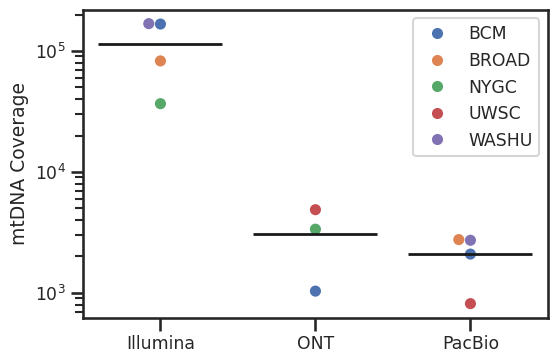

In [7]:
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

plt.figure(figsize=(6, 4))


sns.swarmplot(
    comb_cov_df,
    x="Seq_Tech",
    y="Mito_Coverage",
  #  style="Center",
    hue="Center",
    s=8,
    legend=True)

sns.boxplot(comb_cov_df,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=10,
            x="Seq_Tech",
            y="Mito_Coverage",
            showfliers=False,
            showbox=False,
            showcaps=False)

plt.yscale('log')
plt.ylabel('mtDNA Coverage')
plt.xlabel('')

plt.savefig("plots/fig2-hapmap_coverage.pdf", dpi=300)
plt.show()


In [8]:
df = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/hprc_truthset_eval/combined_tables/HPRC.vcfeval.by_sample.all.tsv", sep='\t')
df_long = pd.melt(df,
                  id_vars=['tool', 'tech', 'sample'],  
                  var_name='Metric',   
                  value_name='Value')

df_long['Metric'] = df_long['Metric'].replace({
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'f_measure': 'F1'
})

conditions = [
    (df_long['tech'] == 'pacbio'),
    (df_long['tech'] == 'ont'),
    (df_long['tech'] == 'illumina'),
]

values = ['PacBio', 'ONT', 'Illumina']
df_long['tech'] = np.select(conditions, values, default='Unknown')


conditions = [
    (df_long['tool'] == 'mitoscope'),
    (df_long['tool'] == 'himito'),
    (df_long['tool'] == 'mitorsaw'),
    (df_long['tool'] == 'mutect2'),

]

values = ['MitoScope', 'Himito', 'Mitorsaw', 'Mutect2']
df_long['tool'] = np.select(conditions, values, default='Unknown')


df_long 


,tool,tech,sample,Metric,Value
0,MitoScope,PacBio,hapmap-pacbio-bcm,true_positives_baseline,97.0000
1,MitoScope,PacBio,hapmap-pacbio-broad,true_positives_baseline,96.0000
2,MitoScope,PacBio,hapmap-pacbio-uwsc,true_positives_baseline,85.0000
3,MitoScope,PacBio,hapmap-pacbio-washu,true_positives_baseline,97.0000
4,MitoScope,ONT,hapmap-ont-bcm,true_positives_baseline,84.0000
...,...,...,...,...,...
149,Mitorsaw,PacBio,hapmap-pacbio-washu,F1,0.5562
150,Mutect2,Illumina,hapmap-illumina-bcm,F1,0.7845
151,Mutect2,Illumina,hapmap-illumina-broad,F1,0.7397
152,Mutect2,Illumina,hapmap-illumina-nygc,F1,0.7364


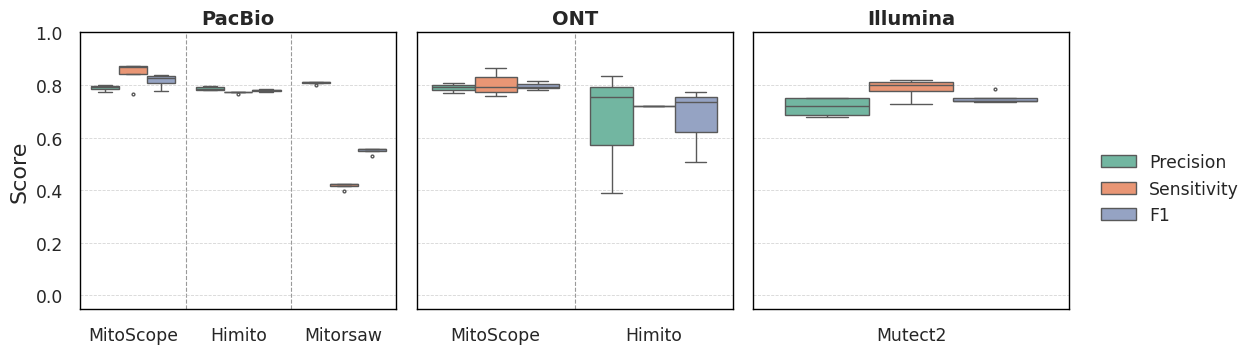

In [9]:

sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

palette = sns.color_palette("Set2", n_colors=3)

g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['Precision', 'Sensitivity', 'F1'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    ticks = ax.get_xticks()
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0,
            )
    
    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

plt.savefig("plots/fig2-hapmap_sens_prec_f1.pdf", dpi=300)
plt.show()

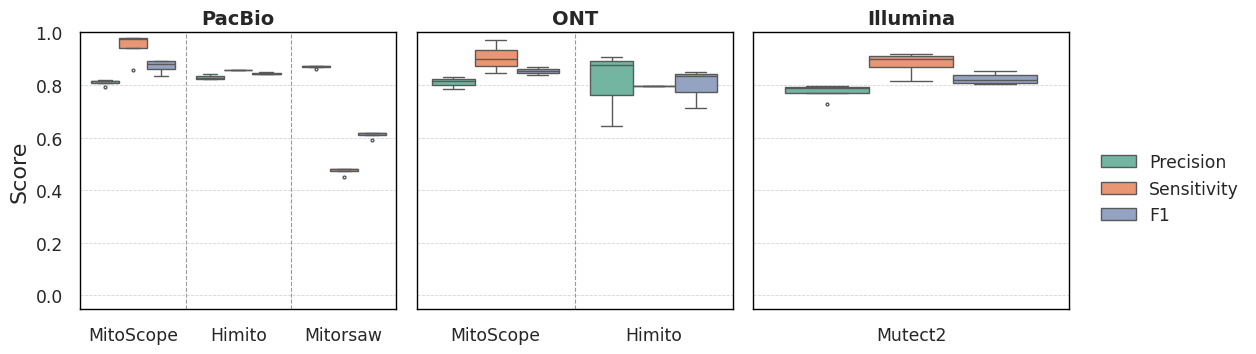

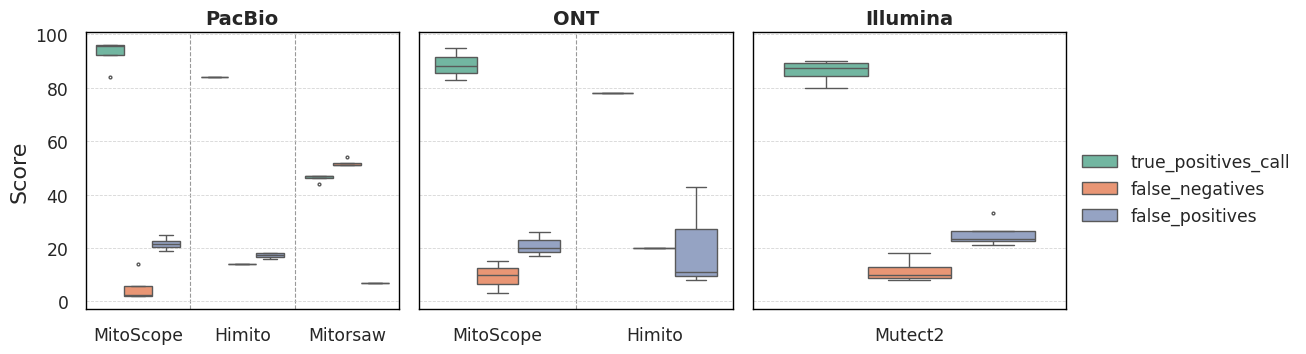

In [10]:
df = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/hprc_truthset_eval/combined_tables/HPRC.vcfeval.by_sample.snvs.tsv", sep='\t')
df_long = pd.melt(df,
                  id_vars=['tool', 'tech', 'sample'],  
                  var_name='Metric',   
                  value_name='Value')

df_long['Metric'] = df_long['Metric'].replace({
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'f_measure': 'F1'
})

conditions = [
    (df_long['tech'] == 'pacbio'),
    (df_long['tech'] == 'ont'),
    (df_long['tech'] == 'illumina'),
]

values = ['PacBio', 'ONT', 'Illumina']
df_long['tech'] = np.select(conditions, values, default='Unknown')


conditions = [
    (df_long['tool'] == 'mitoscope'),
    (df_long['tool'] == 'himito'),
    (df_long['tool'] == 'mitorsaw'),
    (df_long['tool'] == 'mutect2'),

]

values = ['MitoScope', 'Himito', 'Mitorsaw', 'Mutect2']
df_long['tool'] = np.select(conditions, values, default='Unknown')


sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

palette = sns.color_palette("Set2", n_colors=3)

g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['Precision', 'Sensitivity', 'F1'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)  # keep full axes box
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    # Get tick positions (x coordinates of categories)
    ticks = ax.get_xticks()

    # Compute midpoints between categories
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0,   # keeps lines behind boxes
            )

    
    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

#plt.savefig("plots/fig2-hapmap_sens_prec_f1.pdf", dpi=300)
plt.show()

g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['true_positives_call', 'false_negatives', 'false_positives'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    hue_order=['true_positives_call', 'false_negatives', 'false_positives'],
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
#g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    ticks = ax.get_xticks()
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0
            )

    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

#plt.savefig("plots/fig2-hapmap_sens_prec_f1.pdf", dpi=300)
plt.show()

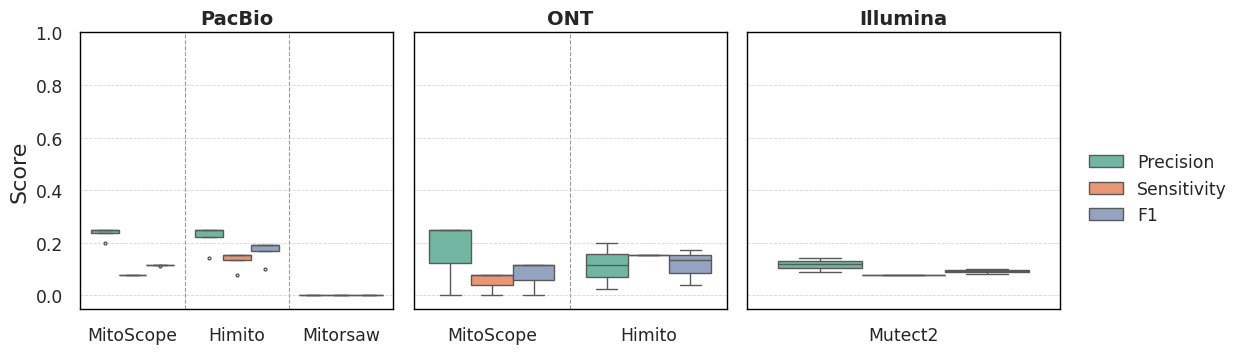

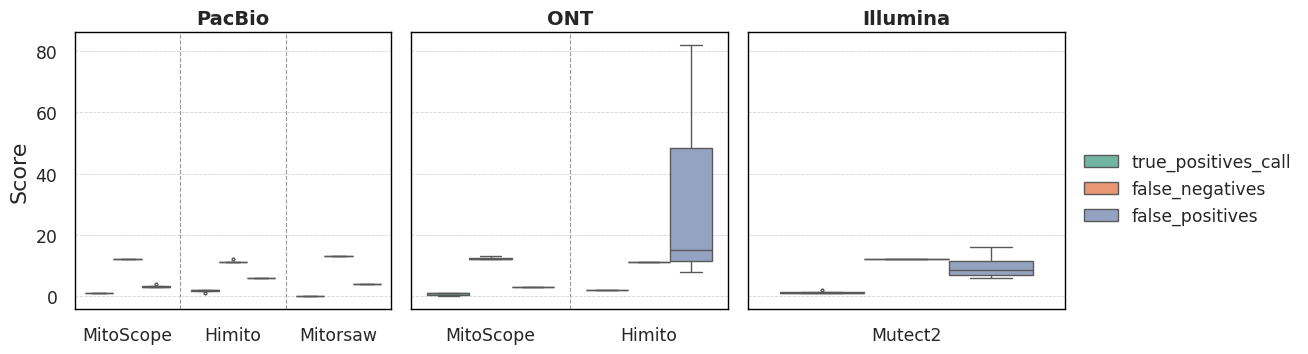

In [11]:
df = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/hprc_truthset_eval/combined_tables/HPRC.vcfeval.by_sample.indels.tsv", sep='\t')
df_long = pd.melt(df,
                  id_vars=['tool', 'tech', 'sample'],  
                  var_name='Metric',   
                  value_name='Value')

df_long['Metric'] = df_long['Metric'].replace({
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'f_measure': 'F1'
})

conditions = [
    (df_long['tech'] == 'pacbio'),
    (df_long['tech'] == 'ont'),
    (df_long['tech'] == 'illumina'),
]

values = ['PacBio', 'ONT', 'Illumina']
df_long['tech'] = np.select(conditions, values, default='Unknown')


conditions = [
    (df_long['tool'] == 'mitoscope'),
    (df_long['tool'] == 'himito'),
    (df_long['tool'] == 'mitorsaw'),
    (df_long['tool'] == 'mutect2'),

]

values = ['MitoScope', 'Himito', 'Mitorsaw', 'Mutect2']
df_long['tool'] = np.select(conditions, values, default='Unknown')


sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)
palette = sns.color_palette("Set2", n_colors=3)

g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['Precision', 'Sensitivity', 'F1'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    ticks = ax.get_xticks()
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0
            )

    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

#plt.savefig("plots/fig2-hapmap_sens_prec_f1.pdf", dpi=300)
plt.show()


g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['true_positives_call', 'false_negatives', 'false_positives'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    hue_order=['true_positives_call', 'false_negatives', 'false_positives'],
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
#g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    ticks = ax.get_xticks()
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0
            )

    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

#plt.savefig("plots/fig2-hapmap_sens_prec_f1.pdf", dpi=300)
plt.show()

In [12]:
## mitoscope heteroplasmy levels vs mutect2 heteroplasmy levels (correlation plot or heat map w R2 value?)
## using mean het values across sites 

mutect_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mutect2/smaht/illumina/hapmap/output/merged.mutect2.filtered.norm.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mutect_df['id'] = mutect_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mutect_df['hp_mutect'] = mutect_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mutect_df['tool'] = 'mutect2'
mutect_df['tech'] = 'illumina'
mutect_df = mutect_df[['id', 'hp_mutect']]
mutect_df


,id,hp_mutect
0,MT-73-A-G,0.963500
1,MT-106-G-A,0.026250
2,MT-150-C-T,0.097750
3,MT-185-G-A,0.935750
4,MT-246-TG-T,0.839750
...,...,...
142,MT-16325-T-C,0.026750
143,MT-16327-C-T,0.027750
144,MT-16488-C-T,0.004291
145,MT-16519-T-C,0.841750


In [13]:
mitoscope_pb_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/pacbio/output/merged.baldur.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitoscope_pb_df['id'] = mitoscope_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitoscope_pb_df['hp_mito_pb'] = mitoscope_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitoscope_pb_df['tool'] = 'mitoscope'
mitoscope_pb_df['tech'] = 'pacbio'
mitoscope_pb_df = mitoscope_pb_df[['id', 'hp_mito_pb']]

mitoscope_pb_df

,id,hp_mito_pb
0,MT-73-A-G,0.957665
1,MT-106-G-A,0.026485
2,MT-150-C-T,0.114343
3,MT-185-G-A,0.929157
4,MT-246-TG-T,0.810405
...,...,...
123,MT-16304-T-C,0.830233
124,MT-16325-T-C,0.027338
125,MT-16327-C-T,0.026545
126,MT-16488-C-T,0.003410


In [14]:
mitoscope_ont_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/hapmap/ont/output/merged.baldur.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitoscope_ont_df['id'] = mitoscope_ont_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitoscope_ont_df['hp_mito_ont'] = mitoscope_ont_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitoscope_ont_df['tool'] = 'mitoscope'
mitoscope_ont_df['tech'] = 'ont'
mitoscope_ont_df = mitoscope_ont_df[['id', 'hp_mito_ont']]

mitoscope_ont_df

,id,hp_mito_ont
0,MT-73-A-G,0.976833
1,MT-106-G-A,0.038583
2,MT-150-C-T,0.096250
3,MT-185-G-A,0.917897
4,MT-246-TG-T,0.808437
...,...,...
123,MT-16304-T-C,0.879883
124,MT-16325-T-C,0.036863
125,MT-16327-C-T,0.029247
126,MT-16488-C-T,0.003320


In [15]:
himito_pb_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/himito/smaht/hapmap/pacbio/output/merged.himito.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

himito_pb_df['id'] = himito_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
himito_pb_df['hp_himito_pb'] = himito_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
himito_pb_df['tool'] = 'himito'
himito_pb_df['tech'] = 'pacbio'
himito_pb_df = himito_pb_df[['id', 'hp_himito_pb']]

himito_pb_df

,id,hp_himito_pb
0,MT-73-A-G,0.954861
1,MT-106-G-A,0.027173
2,MT-150-C-T,0.110371
3,MT-185-G-A,0.921026
4,MT-246-TG-T,0.808204
...,...,...
106,MT-16301-C-T,0.113340
107,MT-16304-T-C,0.829745
108,MT-16325-T-C,0.026597
109,MT-16327-C-T,0.026597


In [16]:
himito_ont_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/himito/smaht/hapmap/ont/output/merged.himito.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

himito_ont_df['id'] = himito_ont_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
himito_ont_df['hp_himito_ont'] = himito_ont_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
himito_ont_df['tool'] = 'himito'
himito_ont_df['tech'] = 'ont'
himito_ont_df = himito_ont_df[['id', 'hp_himito_ont']]

himito_ont_df

,id,hp_himito_ont
0,MT-65-TG-T,0.051745
1,MT-70-G-C,0.027185
2,MT-71-GTA-G,0.028387
3,MT-73-A-G,0.935343
4,MT-106-G-A,0.022953
...,...,...
200,MT-16374-AC-A,0.027318
201,MT-16383-A-G,0.020790
202,MT-16387-A-C,0.023692
203,MT-16431-CA-C,0.024604


In [17]:
mitorsaw_pb_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitorsaw/smaht/hapmap/pacbio/output/merged.mitorsaw.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitorsaw_pb_df['id'] = mitorsaw_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitorsaw_pb_df['hp_mitorsaw_pb'] = mitorsaw_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitorsaw_pb_df['tool'] = 'mitorsaw'
mitorsaw_pb_df['tech'] = 'pb'
mitorsaw_pb_df = mitorsaw_pb_df[['id', 'hp_mitorsaw_pb']]

In [18]:
merged_df = pd.merge(mutect_df, mitoscope_pb_df, on="id", how="inner")
final_merged_df = pd.merge(merged_df, mitoscope_ont_df, on="id", how="inner")

final_merged_df['ref'] = final_merged_df['id'].str.split("-", expand=True)[2]
final_merged_df['alt'] = final_merged_df['id'].str.split("-", expand=True)[3]

final_merged_df['indel'] = final_merged_df.apply(lambda row: 'indel' if (len(row['ref']) > 1 or len(row['alt']) > 1) else 'snv', axis=1)
final_merged_df = final_merged_df.drop(columns=['ref','alt'])

final_merged_df['pos'] = final_merged_df['id'].str.split('-', expand=True)[1].astype(int)
final_merged_df = final_merged_df[~(final_merged_df['pos'].isin(poly_homopolymer_regions))]
final_merged_df = final_merged_df.drop(columns=["pos"])

final_merged_df

,id,hp_mutect,hp_mito_pb,hp_mito_ont,indel
0,MT-73-A-G,0.963500,0.957665,0.976833,snv
1,MT-106-G-A,0.026250,0.026485,0.038583,snv
2,MT-150-C-T,0.097750,0.114343,0.096250,snv
3,MT-185-G-A,0.935750,0.929157,0.917897,snv
4,MT-246-TG-T,0.839750,0.810405,0.808437,indel
...,...,...,...,...,...
110,MT-16304-T-C,0.880000,0.830233,0.879883,snv
111,MT-16325-T-C,0.026750,0.027338,0.036863,snv
112,MT-16327-C-T,0.027750,0.026545,0.029247,snv
113,MT-16488-C-T,0.004291,0.003410,0.003320,snv


In [19]:
corr = final_merged_df.drop(columns=['id', 'indel']).corr()
corr

,hp_mutect,hp_mito_pb,hp_mito_ont
hp_mutect,1.000000,0.995040,0.995933
hp_mito_pb,0.995040,1.000000,0.998956
hp_mito_ont,0.995933,0.998956,1.000000


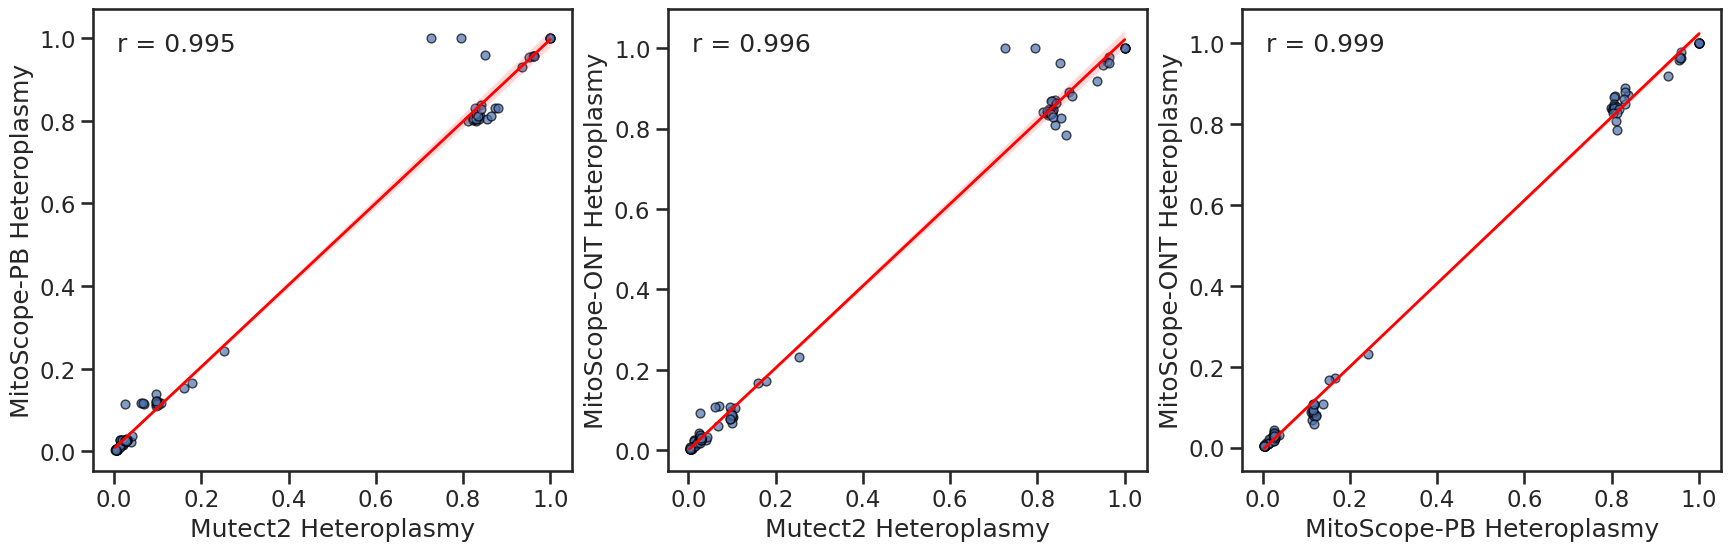

In [20]:
sns.set_theme(style="ticks", context="talk", font_scale=1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

common_kws = dict(scatter_kws={'s': 40, 'alpha': 0.7, 'edgecolor': 'black'},
                  line_kws={'color': 'red', 'lw': 2})

sns.regplot(data=final_merged_df, x='hp_mutect', y='hp_mito_pb', ax=axes[0], **common_kws)
axes[0].set_xlabel('Mutect2 Heteroplasmy')
axes[0].set_ylabel('MitoScope-PB Heteroplasmy')
axes[0].text(0.05, 0.95, f"r = {corr.loc['hp_mutect', 'hp_mito_pb']:.3f}",
             transform=axes[0].transAxes,
             ha="left", va="top")

sns.regplot(data=final_merged_df, x='hp_mutect', y='hp_mito_ont', ax=axes[1], **common_kws)
axes[1].set_xlabel('Mutect2 Heteroplasmy')
axes[1].set_ylabel('MitoScope-ONT Heteroplasmy')
axes[1].text(0.05, 0.95, f"r = {corr.loc['hp_mutect', 'hp_mito_ont']:.3f}",
             transform=axes[1].transAxes,
             ha="left", va="top")

sns.regplot(data=final_merged_df, x='hp_mito_pb', y='hp_mito_ont', ax=axes[2], **common_kws)
axes[2].set_xlabel('MitoScope-PB Heteroplasmy')
axes[2].set_ylabel('MitoScope-ONT Heteroplasmy')
axes[2].text(0.05, 0.95, f"r = {corr.loc['hp_mito_pb', 'hp_mito_ont']:.3f}",
             transform=axes[2].transAxes,
             ha="left", va="top")

plt.savefig("plots/fig2-hapmap_heteroplasmy_correlation_plots.pdf", dpi=300, bbox_inches='tight')
plt.show()



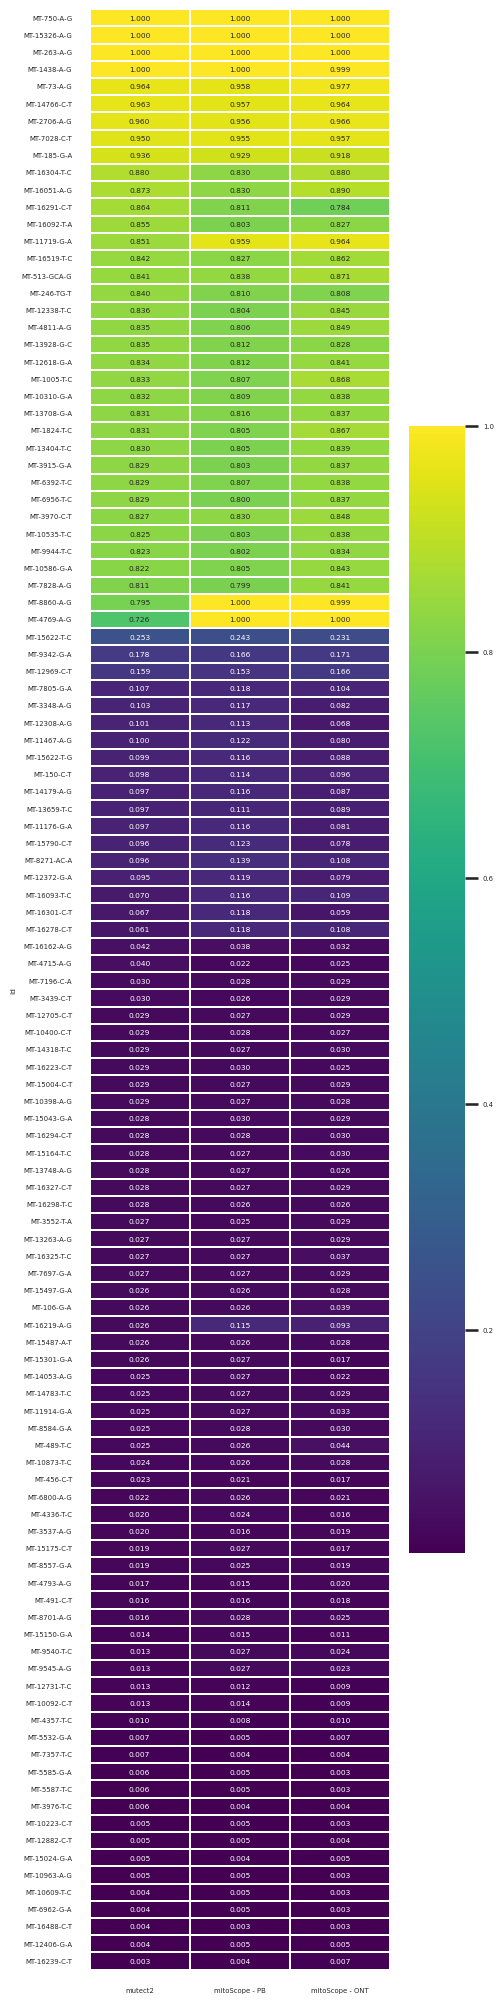

In [21]:
sns.set_theme(style="whitegrid", context="talk", font_scale=0.3)

labels = ['mutect2', 'mitoScope - PB', 'mitoScope - ONT']
df_sorted = final_merged_df.sort_values("hp_mutect", ascending=False).drop(columns=['indel'])

plt.figure(figsize=(5, 20))  # flip aspect ratio

ax = sns.heatmap(
    df_sorted.set_index(["id"]),
    xticklabels=labels,
    annot=True,
    cmap="viridis",
    linewidths=0.1,
    fmt=".3f"
)

plt.title("")
plt.tight_layout()
plt.savefig("plots/fig2-hapmap_heteroplasmy_concordance_heatmap.pdf", dpi=300)
plt.show()

df_sorted.to_csv('tables/hapmap_heteroplasmy_concordance.csv', index=False)


In [ ]:
## pileup verification for discordant positions (8860,4769)
positions = [8860, 4769]
indir="/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/pileup_bases"

comb_x = pd.DataFrame()
for s in df['sample'].unique():
    for p in positions:
        x = pd.read_csv(f'{indir}/{s}.{p}.base_comp.txt', sep=" ", names=['freq', 'base'])
        x['sample'] = s
        x['pos'] = p
        comb_x = pd.concat([comb_x, x])
    
comb_x['base'] = comb_x['base'].str.upper()
#comb_x = comb_x[~comb_x['base'].isin(['*'])]

comb_x_collapsed = comb_x.groupby(['sample', 'pos', 'base'])['freq'].sum().reset_index()
comb_x_collapsed['prop'] = comb_x_collapsed['freq'] / comb_x_collapsed.groupby(['sample', 'pos'])['freq'].transform('sum')
comb_x_collapsed[['donor', 'tech', 'center']] = comb_x_collapsed['sample'].str.split('-', expand=True)
comb_x_collapsed

FileNotFoundError: [Errno 2] No such file or directory: '/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/pileup_bases/benchmark/hapmap-pacbio-bcm.13042.base_comp.txt'

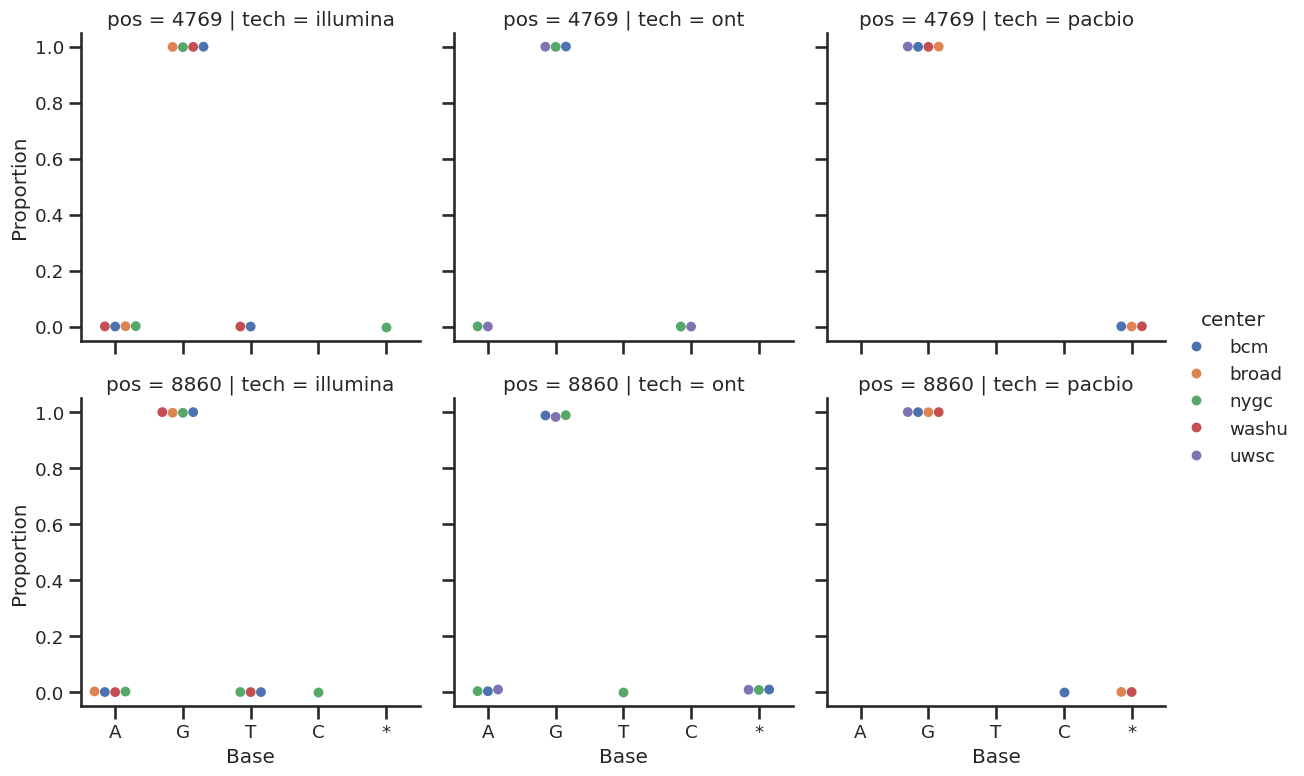

In [95]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

# Use sns.catplot() instead of sns.barplot()
g = sns.catplot(
    data=comb_x_collapsed,
    x='base',
    order=['A', 'G', 'T', 'C', '*'],
    y='prop',
    hue='center',
    row='pos',
    col='tech',
    kind='swarm',
    height=4,
    aspect=1,
    s=50
)

g.set_axis_labels("Base", "Proportion")
plt.show()
